In [1]:
import sys
sys.path.append('../../')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import cycle

from src import (generate_receptor_indices,
                generate_cascading_receptors,
                generate_targeted_receptors,
                plot_family_summary,                
                plot_latent_radar_chart,
                evaluate_model,
                plot_summary,
                plot_latent_umap,
                receptor_distances,
                full_array_entropy,
                mean_receptor_distance)
from run import initialize,train,test
from src.IO import ExperimentLogger
from run.run import estimate_memory_usage


In [38]:
n_units_list = [50]#, 10, 15, 20, 30, 50]
k_sub = 5
n_families = 100
N_train = 2**16
print(N_train)
n_units = 5

CONF = {
    # environment
        # energies
    "n_families": n_families,
    "latent_dim": 20,
    "average_family_distance":10., # distance  between the family centers
        # concentration
    "init_means": [np.random.randint(1, 8) for _ in range(n_families)], # Fixed 
    "shape_sigma": 1.2,
    # receptor 
    "k_sub": k_sub, # number of sub-units
    "temperature": .1, # temperature of the sigmoid that approximate a binary answer
    "n_units" : n_units, # number of genes
    "receptor_indices" : torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)], dtype=torch.long), # actual receptors considered
    
    # training characteristics
    "batch_size": N_train,
    "epochs": 5000,


    "lr": 0.05, # learning rate
    "exact_loss": False, # type of loss
    "cov_weight":20.,
    "use_scheduler":False
    
}

65536


Fitting UMAP... (This may take a few seconds)


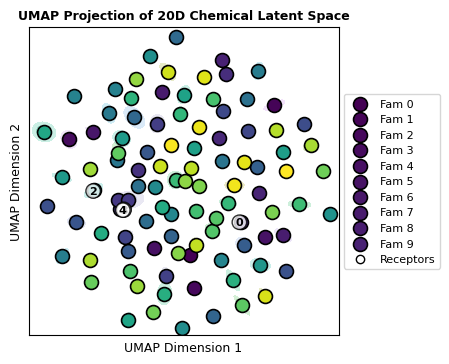

In [39]:
env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False)
# Plot the latent space visualization for each experiment
fig, ax = plot_latent_umap(env, CONF['receptor_indices'])

In [40]:
# Print memory stats
estimated_mb = estimate_memory_usage(CONF)
if estimated_mb > 3500:  # Assuming you have ~3.6GB free as per your previous error
    print("WARNING: This will probably OOM. Reduce CONF['batch_size'] or CONF['eval_batch_size'].")

--- VRAM Memory Estimation ---
CUDA Context Overhead : 1024.0 MB
Train Pass (w/ Grad)  : 52.5 MB  (Batch=65536)
Evaluation Pass       : 26.7 MB  (Batch=100000)
------------------------------
Estimated Peak VRAM   : 1076.5 MB
------------------------------


In [41]:
for n_units in n_units_list:
    print(f"\n--- Starting training for n_units = {n_units} ---")
    
    CONF["n_units"] = n_units
    CONF["receptor_indices"] = torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)], dtype=torch.long)

    env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False)
    
    print(env.base_energy_u)

    train_out = train(CONF, env, rec, loss_fn, optimize,measurement_fns=[full_array_entropy,mean_receptor_distance,])


--- Starting training for n_units = 50 ---
Parameter containing:
tensor([8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880,
        8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880,
        8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880,
        8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880,
        8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880, 8.8880,
        8.8880, 8.8880, 8.8880, 8.8880, 8.8880], device='cuda:0',
       requires_grad=True)
Training for 5000 epochs...


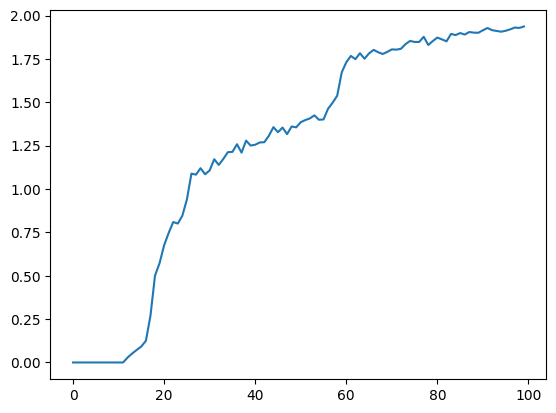

In [42]:
plt.plot(train_out['full_array_entropy'])

In [43]:
print(env.base_energy_u)

print(env.unit_latent)

Parameter containing:
tensor([  5.8249,   8.8880,   8.8880, -69.4311,   8.8880,   7.4961,   7.3453,
          8.9801,   7.4113,   8.8880,   7.7609,   6.0350,   8.8152,   8.8880,
          9.5927,   7.1115,  10.3880,   7.3099,   8.8512,   8.8880,   7.4063,
          8.8880,  10.0324,   8.8880,  10.0671,   8.8880,   8.8880,   8.8880,
          8.8880,  10.4853,   8.8889,   9.6789,   8.8880,   8.9322,   8.8880,
        -60.6482,   8.1913,   7.3948,   8.8880,   8.8880,   7.5461,   5.6092,
          8.8880, -79.8572,   8.8880,   7.2979,   6.2443,   8.4111,   8.8880,
          8.8880], device='cuda:0', requires_grad=True)
Parameter containing:
tensor([[-4.7369e-01, -3.3784e+00,  7.1194e-01, -2.4782e+00,  8.6491e-01,
          1.0935e+00, -1.3658e+00, -8.5606e-01, -1.0921e+00, -1.7967e+00,
          5.0248e-01,  1.7870e+00, -2.6560e+00,  1.3648e-01,  2.7315e+00,
         -2.0120e-01, -2.2489e+00,  1.5938e+00,  2.0157e-01, -4.4547e-01],
        [-4.4202e-02, -6.4163e-01,  8.8688e-01, -1.2646e+

Fitting UMAP... (This may take a few seconds)


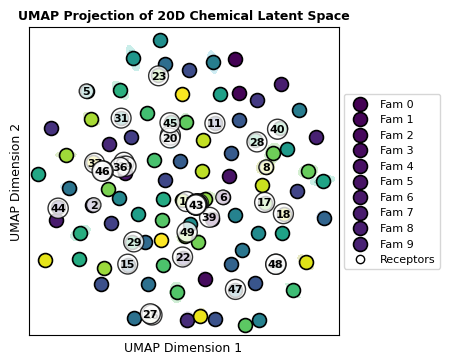

In [44]:
# Plot the latent space visualization for each experiment
fig, ax = plot_latent_umap(env, CONF['receptor_indices'])

(<Figure size 400x300 with 3 Axes>,
 (<Axes: title={'center': 'Global Receptor Array Binary Response'}, ylabel='Activity Probability $p(a=1)$'>,
  <Axes: xlabel='Concentration (M)', ylabel='p(c)'>,
  <Axes: xlabel='Global Mass'>))

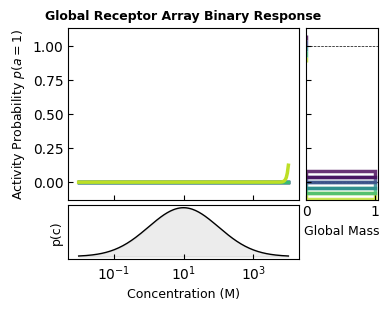

In [25]:
plot_summary(env,rec,CONF['receptor_indices'],loss_fn=loss_fn)